In [2]:
# %%
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import time

import cvxpy as cp

from vempc.core.mpc import MPCProblem
from vempc.core import mpc as mpc_utils
from vempc.core.constraints import ConstraintPenalty
from vempc.core.variational import VariationalMPC

from vempc.examples import pendulum
from vempc.solvers import qpMPC
from vempc.solvers import sampling

from vempc.utils import print as print_utils

np.random.seed(0)

## Linearized cart-pole model and discretization
The continuous-time linearized cart-pole dynamics use the state $x = [p,\dot p,\theta,\dot\theta]^\top$ and input
$u$ (cart force):
$$
\begin{align*}
\dot p &= \dot p\\
\ddot{p} &= \frac{m g}{M}\,\theta + \frac{1}{M}u\\
\dot\theta &= \dot\theta\\
\ddot{\theta} &= -\frac{(M+m)g}{lM}\,\theta - \frac{1}{lM}u
\end{align*}
$$ 

The code discretizes this linear system with step size $dt$ to obtain the discrete matrices $(A,B)$ used in
MPC: $x_{k+1} = A x_k + B u_k$.

---
This block also sets the LQ weights in the finite-horizon cost

$$ J_0(x_0,U_0) = x_N^\top Q_f x_N + \sum_{k=0}^{N-1}(x_k^\top Q x_k + u_k^\top R u_k) $$

and the polyhedral bounds

$$
\begin{align*}
X &:= \{x: G_x x \le h_x\}\\
U &:= \{u: G_u u \le h_u\}
\end{align*}
$$

with
 $G_x=[I;-I]$ and $G_u=[I;-I]$.



In [3]:
# system parameters
M, m, l, g = 1.0, 0.1, 0.5, 9.81
dt = 0.01

Ac, Bc = pendulum.linearized_cartpole_continuous(M=M, m=m, l=l, g=g)
A, B = pendulum.discretize(Ac, Bc, dt)

n, m_in = A.shape[0], B.shape[1]

# Horizon and simulation length
N = 20           # MPC horizon
T_steps = 2000    # simulation steps

# Weights (tune these as needed)
# Primary objective is to send theta to zero
Q  = np.diag([10.0, 1.0, 200.0, 5.0])   # [pos, vel, theta, omega]
R  = np.diag([0.2])
Qf = 5.0 * Q

# Constraints: |x_i| <= x_max_i, |u| <= u_max
x_max     = 2.0
v_max     = 1.0
theta_max = 0.35   
omega_max = 3.0

u_max = 1.0

x_bound = np.array([x_max, v_max, theta_max, omega_max])

# Polyhedral bounds Gx x <= hx with Gx = [I; -I]
Gx = np.vstack([np.eye(n), -np.eye(n)])
hx = np.hstack([x_bound, x_bound])

Gu = np.vstack([np.eye(m_in), -np.eye(m_in)])
hu = np.hstack([np.array([u_max]), np.array([u_max])])


# Uncomment to print
# print_utils.print_setup(M, m, l, g, dt, Ac, Bc, A, B, N, T_steps, Q, R, Qf,
                #   x_max, v_max, theta_max, omega_max, u_max,
                #   x_bound, Gx, hx, Gu, hu)


## Compact representation of MPC
Using the compact MPC representation (paper Sec. IV-A), the state
trajectory satisfies

$$ 
X = \Lambda x_0 + \Psi U 
$$ 

The quadratic cost is

$$ 
J_0(x_0,U) = x_0^\top P x_0 + x_0^\top S U + \tfrac12 U^\top H U 
$$

with

$$
\begin{align*}
P &= Q + \Lambda^\top \bar Q \Lambda \\
S &= 2\Lambda^\top \bar Q \Psi \\
H &= 2(\bar R + \Psi^\top \bar Q \Psi) 
\end{align*}
$$

State/input constraints are condensed into
$ G U \le h(x_0) $, where

$$ G = \begin{bmatrix}\bar G_x\Psi \\ \bar G_u\end{bmatrix} $$

and

$$ h(x_0) = \begin{bmatrix}\bar h_x - \bar G_x\Lambda x_0 \\ \bar h_u\end{bmatrix} $$

The residual is 

$$ g(U;x_0) := G U - h(x_0) $$

and the feasible set is
$ F(x_0) := \{U : g(U;x_0) \le 0\} $ with desirability
$ r(U;x_0) := \mathbf{1}_{F(x_0)}(U) $.



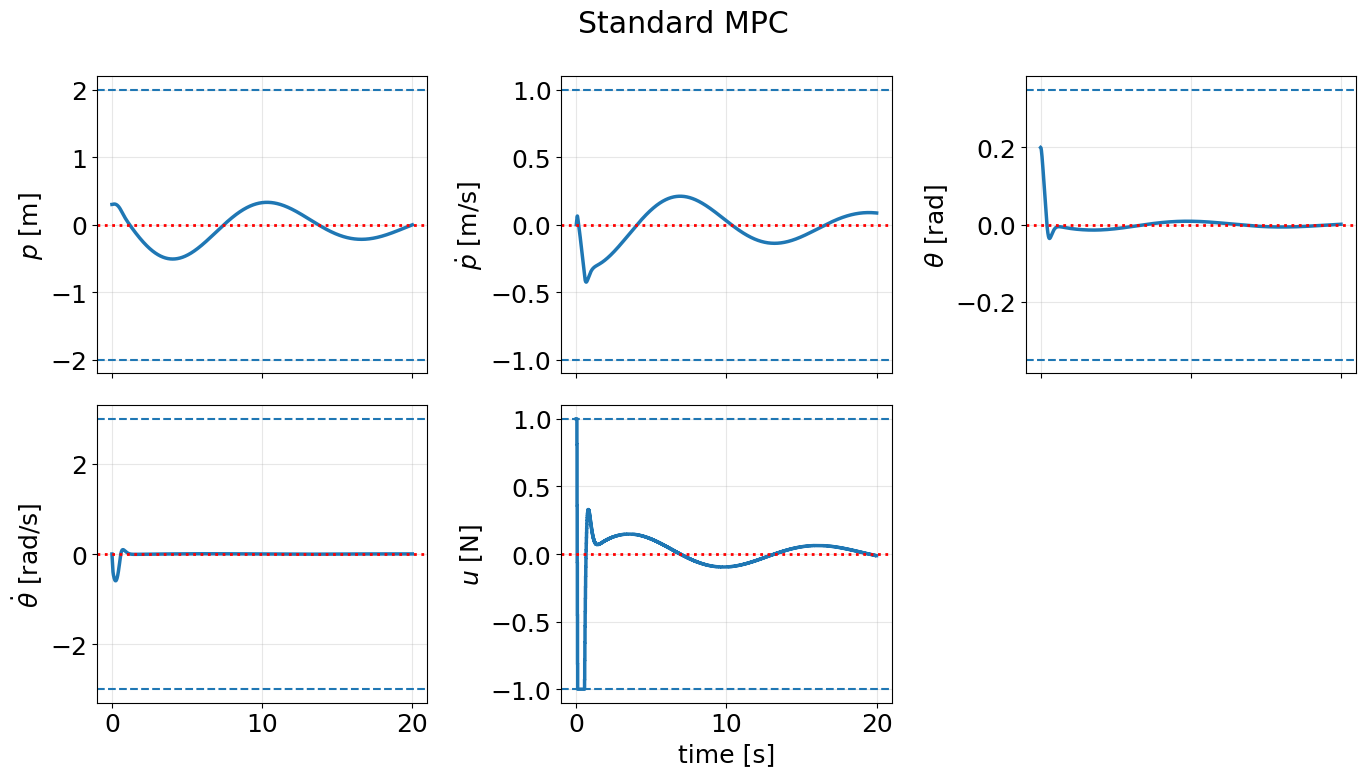

In [4]:
# Build condensed MPC using core implementation
mpc = MPCProblem(A, B, Q, R, Qf, N)

P, S, H = mpc.P, mpc.S, mpc.H
Lambda, Psi = mpc.Lambda, mpc.Psi

G, h_of_x0 = mpc.build_constraint_matrices(Gx, hx, Gu, hu)
penalty = ConstraintPenalty(G, h_of_x0)

Nm = mpc.Nm
p_total = G.shape[0]

# Standard QP-MPC (explicit constraints)
prob_qp_std, U_var_std, q_par_std, h_par_std = qpMPC.make_standard_qp_solver(H, G)


def solve_standard_mpc(x0, warm_start_U=None, verbose=False):
    return qpMPC.solve_standard_mpc(
        x0,
        S=S,
        h_of_x0=h_of_x0,
        m_in=m_in,
        prob=prob_qp_std,
        U_var=U_var_std,
        q_par=q_par_std,
        h_par=h_par_std,
        warm_start_U=warm_start_U,
        verbose=verbose,
    )

# initial condition (small deviation from upright)
x0 = np.array([0.3, 0.0, 0.20, 0.0])  # theta=0.20 rad

# Controller: Standard MPC (QP)
def ctrl_standard(x, U_warm):
    u, Useq = solve_standard_mpc(x, warm_start_U=U_warm, verbose=False)
    return u, Useq

# run baseline standard MPC controller
xs_std, us_std, info_std, t_std = mpc_utils.simulate(
    "Standard MPC", x0, ctrl_standard, A=A, B=B, T_steps=T_steps
)

baseline_results = {
    "Standard MPC": {
        "xs": xs_std,
        "us": us_std,
        "runtime": t_std,
        "cost": mpc_utils.trajectory_cost(xs_std, us_std, Q=Q, R=R, Qf=Qf),
        "viol": mpc_utils.max_constraint_violation(xs_std, us_std, Gx=Gx, hx=hx, Gu=Gu, hu=hu),
    },
}

t = np.arange(T_steps + 1) * dt
tu = np.arange(T_steps) * dt

def plot_mpc(xs, us, title_prefix="Standard Constrained MPC"):
    plt.rcParams.update({"font.size": 18})
    fig, ax = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
    ax = ax.ravel()

    ax[0].plot(t, xs[:, 0], label=title_prefix, linewidth=2.5)
    ax[0].axhline(0.0, color="red", linestyle=":", linewidth=2.0)
    ax[0].axhline(+x_max, linestyle="--")
    ax[0].axhline(-x_max, linestyle="--")
    ax[0].set_ylabel(r"$p$ [m]")
    ax[0].grid(True, alpha=0.3)

    ax[1].plot(t, xs[:, 1], label=title_prefix, linewidth=2.5)
    ax[1].axhline(0.0, color="red", linestyle=":", linewidth=2.0)
    ax[1].axhline(+v_max, linestyle="--")
    ax[1].axhline(-v_max, linestyle="--")
    ax[1].set_ylabel(r"$\dot{p}$ [m/s]")
    ax[1].grid(True, alpha=0.3)

    ax[2].plot(t, xs[:, 2], label=title_prefix, linewidth=2.5)
    ax[2].axhline(0.0, color="red", linestyle=":", linewidth=2.0)
    ax[2].axhline(+theta_max, linestyle="--")
    ax[2].axhline(-theta_max, linestyle="--")
    ax[2].set_ylabel(r"$\theta$ [rad]")
    ax[2].grid(True, alpha=0.3)

    ax[3].plot(t, xs[:, 3], label=title_prefix, linewidth=2.5)
    ax[3].axhline(0.0, color="red", linestyle=":", linewidth=2.0)
    ax[3].axhline(+omega_max, linestyle="--")
    ax[3].axhline(-omega_max, linestyle="--")
    ax[3].set_ylabel(r"$\dot{\theta}$ [rad/s]")
    ax[3].grid(True, alpha=0.3)

    ax[4].step(tu, us[:, 0], where="post", label=title_prefix, linewidth=2.5)
    ax[4].axhline(0.0, color="red", linestyle=":", linewidth=2.0)
    ax[4].axhline(+u_max, linestyle="--")
    ax[4].axhline(-u_max, linestyle="--")
    ax[4].set_ylabel(r"$u$ [N]")
    ax[4].set_xlabel("time [s]")
    ax[4].grid(True, alpha=0.3)

    ax[5].axis("off")


    fig.suptitle(f"{title_prefix}")
    plt.tight_layout()
    plt.show()

plot_mpc(xs_std, us_std, title_prefix="Standard MPC")

# Uncomment to print
# print_utils.print_condensed_mpc(P, S, H, Lambda, Psi, G)


## QP-MPC using Polynomial Surrogate

Consider the indicator function 

$$\phi(U;x_0) := 
\begin{cases}
    0, & U\in F(x_0), \\
    \infty, & \text{otherwise}.
\end{cases}$$

Using this, we can reformulate the standard constrained QP into an unconstrained optimization problem:

$$\min_{U\in\mathbb{R}^{Nm}} \; \tfrac12 U^\top H U + (S^\top x_0)^\top U +\phi(U;x_0)$$

The constant term $x_0^\top P x_0$ is omitted since it does not affect the
optimizer. The solver returns the optimal sequence $U^*$ and we apply the
first input $u_0^*$.

This encodes the desirability through the relation 

$$\exp\left( - \dfrac{\phi(U;x_0)}{\lambda}\right) = \mathbf{1}_{F(x_0)}(U)$$

Since the desirability is hard to evaluate using HE, we replace it with a polynomial surrogate.


---

Recall that $ F(x_0) := \{U : g(U;x_0) \le 0\} $. We denote each element of $g(U;x_0)$ by $g_j(U;x_0)$ for $j=1,\ldots,p$.
We quantify the constraint violation using the ReLU function $[\cdot]_+$. Namely, we define the aggregate violation score 

$$s(U;x_0) :=\sum_{j=1}^p \left[g_j(U;x_0) \right]_+$$

We approximate the nonlinear ReLU function with a Chebyshev polynomial.
Fix a bound $B_l>0$ (`cheb_bound`) and a polynomial degree $l$ (`cheb_order`).  
On the normalized interval $\rho\in[-1,1]$, construct a degree-$l$ polynomial approximation for the function
$$
\rho \mapsto B_l[\rho]_+
$$
denoted by 
$$
\hat{h}_l(\rho) = \sum_{k=0}^l \rho^k
$$
With this, we define a polynomial 
$$
h_l(\gamma) = \hat{h}_l\left(\frac{\gamma}{B_l} \right)
$$
that satisfies the uniform approximation error bound for all $\gamma\in[-B_l,B_l]$.

---

The polynomial surrogate for the violation score is defined as
$$
s_l(U;x_0) := \sum_{j=1}^p h_l(g_j(U;x_0))
$$
The unconsrained reformulation becomes 

$$\min_{U\in\mathbb{R}^{Nm}} \; \tfrac12 U^\top H U + (S^\top x_0)^\top U +\eta s_l(U;x_0)$$
where $\eta$ is a sharpness parameter.


In [5]:
# Chebyshev approximation settings for the surrogate penalty (ReLU)
cheb_order = 3
cheb_bound = 20.0  # tuned to match standard MPC
eta_surrogate = 50.0  # tuned to match standard MPC
surrogate_maxiter = 5000
surrogate_ftol = 1e-8
surrogate_gtol = 1e-4

surrogate_solver = qpMPC.make_surrogate_qp_solver(
    H, G, cheb_order=cheb_order, cheb_bound=cheb_bound, eta=eta_surrogate
)


def solve_surrogate_mpc(x0, warm_start_U=None, verbose=False):
    return qpMPC.solve_surrogate_mpc(
        x0,
        S=S,
        h_of_x0=h_of_x0,
        m_in=m_in,
        solver=surrogate_solver,
        warm_start_U=warm_start_U,
        verbose=verbose,
        maxiter=surrogate_maxiter,
        ftol=surrogate_ftol,
        gtol=surrogate_gtol,
    )

# Chebyshev indicator approximation (for variational sampling weights)
indicator_solver = qpMPC.make_indicator_qp_solver(
    H, G, cheb_order=cheb_order, cheb_bound=cheb_bound, eta=1.0
)


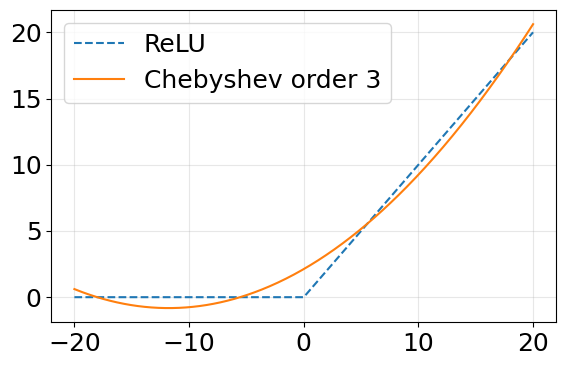

In [29]:
# %%
# Plot Chebyshev ReLU approximation
z = np.linspace(-cheb_bound, cheb_bound, 400)
p = qpMPC.eval_relu_poly(z, surrogate_solver['coeffs'], cheb_bound, clip=True)
plt.figure(figsize=(6, 4))
plt.plot(z, np.maximum(0, z), '--', label='ReLU')
plt.plot(z, p, label=f'Chebyshev order {cheb_order}')

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


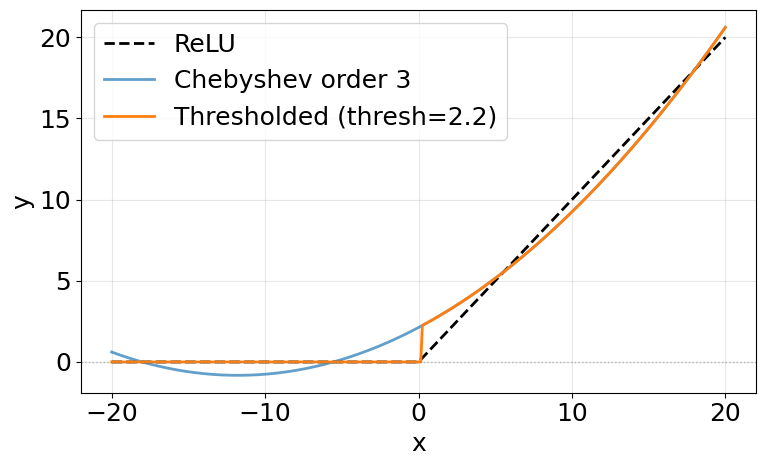

In [39]:
# Apply threshold to force small values to zero
z = np.linspace(-cheb_bound, cheb_bound, 400)
p = qpMPC.eval_relu_poly(z, surrogate_solver['coeffs'], cheb_bound, clip=True)

threshold = 2.2  # threshold

p_thresholded = p.copy()
p_thresholded[np.abs(p) < threshold] = 0.0

plt.figure(figsize=(8, 5))
plt.plot(z, np.maximum(0, z), '--', linewidth=2, label='ReLU', color='black')
plt.plot(z, p, label=f'Chebyshev order {cheb_order}', linewidth=2, alpha=0.7)
plt.plot(z, p_thresholded, label=f'Thresholded (thresh={threshold})', linewidth=2)

plt.grid(True, alpha=0.3)
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(y=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.show()

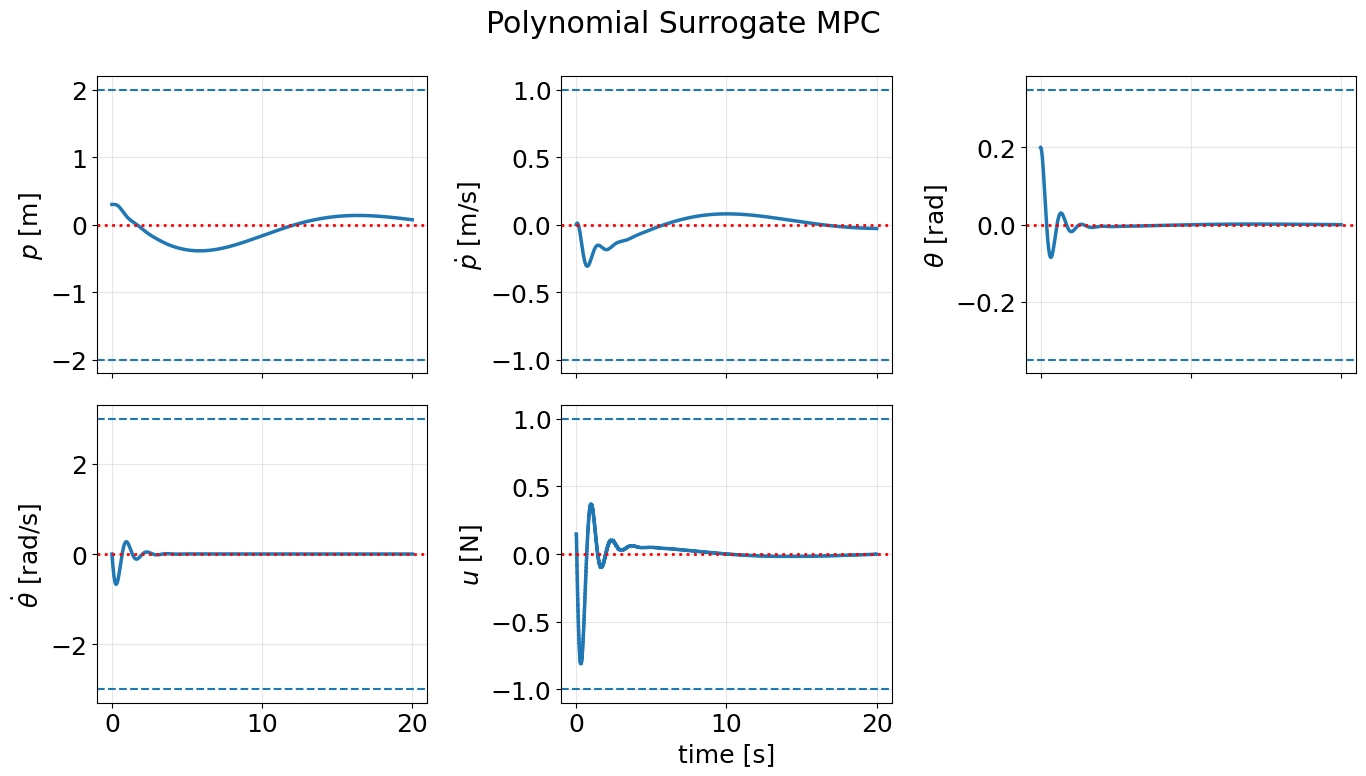

In [40]:
# Controller: Polynomial surrogate MPC (unconstrained)
def ctrl_surrogate(x, U_warm):
    u, Useq = solve_surrogate_mpc(x, warm_start_U=U_warm, verbose=False)
    return u, Useq

# run polynomial surrogate MPC controller
xs_sur, us_sur, info_sur, t_sur = mpc_utils.simulate(
    "Polynomial Surrogate MPC", x0, ctrl_surrogate, A=A, B=B, T_steps=T_steps
)

baseline_results["Polynomial Surrogate MPC"] = {
    "xs": xs_sur,
    "us": us_sur,
    "runtime": t_sur,
    "cost": mpc_utils.trajectory_cost(xs_sur, us_sur, Q=Q, R=R, Qf=Qf),
    "viol": mpc_utils.max_constraint_violation(xs_sur, us_sur, Gx=Gx, hx=hx, Gu=Gu, hu=hu),
}

plot_mpc(xs_sur, us_sur, title_prefix="Polynomial Surrogate MPC")


## Variational MPC sampling (tilted Gaussian, plaintext)

Let $\kappa_0 = \mathcal{N}(0,\Sigma_0)$ be the nominal distribution. Through exponential tilting, we obtain 
$$
\tilde{\kappa}(\cdot \mid x_0) := \mathcal{N}(m_U(x_0), \Sigma_U),
$$
where
$$
\begin{align*}
    m_U(x_0) &:= -\frac{1}{\lambda} \Sigma_U S^\top x_0 \\
    \Sigma_U &:= \left( \Sigma_0^{-1} + \frac{1}{\lambda} H \right)^{-1}
\end{align*}
$$

From this distribution, samples are generated as 
$$
U^{(i)} = m_U(x_0) + L_U \xi^{(i)}, ~~~~ i =1,\ldots, K,
$$
where $\Sigma_U = L_UL_U^\top$ is the Cholesky factorization, $\xi^{(i)}\sim \mathcal{N}(0,I)$, and $K\in\mathbb{N}$ is the sample number.

With the polynomial surrogate, 
$$
r_l^{(i)} = \exp \left( - \eta s_l(U^{(i)} ; x_0) \right)
$$
the variational approximate is obtained as 
$$
\hat{U}_{K,l}(x_0) = \dfrac{\sum_{i=1}^K U^{(i)}r_l^{(i)}}{\sum_{i=1}^K r_l^{(i)}}
$$


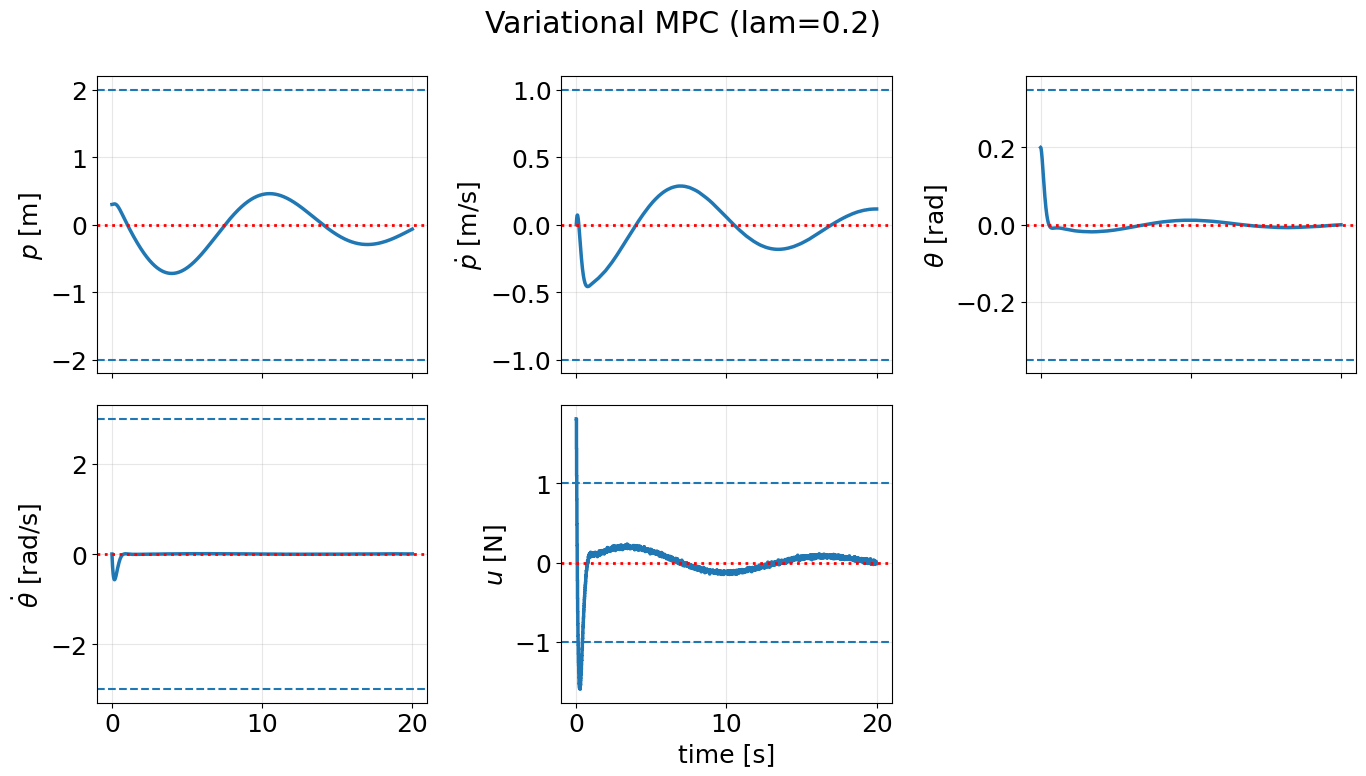

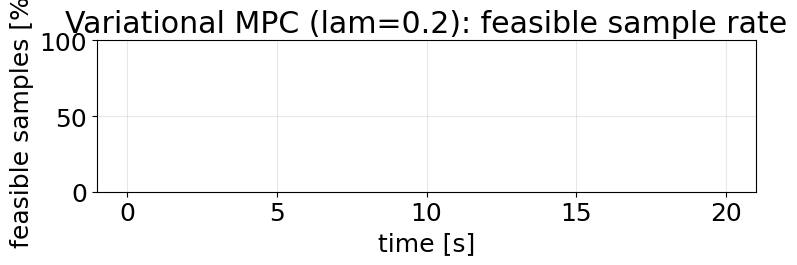

In [37]:
# Variational sampling MPC (polynomial surrogate weights)
sigma0 = 1.0  # tuned for >30% feasible sample rate
Sigma0 = (sigma0**2) * np.eye(Nm)
K_samples = 2000  # number of samples
eta_variational = 0.002  # tuned for >30% feasible sample rate
lambda_plot = 0.2
lambda_values = [lambda_plot]

variational_runs = {}
for lam in lambda_values:
    variational = VariationalMPC(mpc_problem=mpc, penalty=penalty, lambda_param=lam, Sigma_0=Sigma0)

    def ctrl_variational(x, _, _variational=variational):
        u, Useq, info = sampling.sample_variational_control(
            x,
            variational=_variational,
            penalty=penalty,
            K=K_samples,
            cheb_coeffs=surrogate_solver["coeffs"],
            cheb_bound=surrogate_solver["bound"],
            cheb_clip=True,
            cheb_eta=eta_variational,
        )
        return u, Useq, info

    xs, us, info, elapsed = mpc_utils.simulate(
        f"Variational (lam={lam})", x0, ctrl_variational, A=A, B=B, T_steps=T_steps
    )

    accept_series = np.array([d.get("accept_rate", np.nan) for d in info], dtype=float)

    variational_runs[lam] = {
        "xs": xs,
        "us": us,
        "info": info,
        "runtime": elapsed,
        "cost": mpc_utils.trajectory_cost(xs, us, Q=Q, R=R, Qf=Qf),
        "viol": mpc_utils.max_constraint_violation(xs, us, Gx=Gx, hx=hx, Gu=Gu, hu=hu),
        "accept": mpc_utils.avg_acceptance(info),
        "accept_series": accept_series,
    }

# Plot one choice of lambda
plot_mpc(
    variational_runs[lambda_plot]["xs"],
    variational_runs[lambda_plot]["us"],
    title_prefix=f"Variational MPC (lam={lambda_plot})",
)

# Plot feasible sample percentage over time
accept_series = variational_runs[lambda_plot]["accept_series"]
t_accept = np.arange(len(accept_series)) * dt
plt.figure(figsize=(8, 3))
plt.plot(t_accept, 100.0 * accept_series, linewidth=2.0)
plt.ylim(0, 100)
plt.xlabel("time [s]")
plt.ylabel("feasible samples [%]")
plt.title(f"Variational MPC (lam={lambda_plot}): feasible sample rate")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [93]:
# Print runtime / cost summary
print("\n=== Runtime / Cost Summary ===")
for name, res in baseline_results.items():
    vx, vu = res["viol"]
    print(f"{name:20s} | runtime={res['runtime']:.3f}s | cost={res['cost']:.3f} | max viol x={vx:.3e}, u={vu:.3e}")

print("\n--- Variational MPC (hard) across lambda ---")
for lam in lambda_values:
    res = variational_runs[lam]
    vx, vu = res["viol"]
    print(f"lam={lam:<4} | runtime={res['runtime']:.3f}s | cost={res['cost']:.3f} | max viol x={vx:.3e}, u={vu:.3e} | accept={res['accept']:.3f}")





=== Runtime / Cost Summary ===
Standard MPC         | runtime=2.328s | cost=1627.957 | max viol x=0.000e+00, u=1.945e-05
Polynomial Surrogate MPC | runtime=3.694s | cost=1228.865 | max viol x=0.000e+00, u=0.000e+00

--- Variational MPC (hard) across lambda ---
lam=0.2  | runtime=75.188s | cost=3011.583 | max viol x=0.000e+00, u=8.178e-01 | accept=0.000


In [94]:
# Plots moved to the standard MPC section above.
